# 11.11.学习率调度器

到目前为止，我们主要关注如何更新权重向量的优化算法，而不是它们的更新速率。然而，调整学习率通常与实际算法同样重要，有如下几方面需要考虑：

* 首先，学习率的大小很重要。如果它太大，优化就会发散；如果它太小，训练就会需要过长时间，或者我们最终只能得到次优的结果。我们之前看到问题的条件数很重要（有关详细信息，请参见[11.06_momentum](./11.06_momentum.ipynb)）。直观地说，这是最不敏感与最敏感方向的变化量的比率。
* 其次，衰减速率同样很重要。如果学习率持续过高，我们可能最终会在最小值附近弹跳，从而无法达到最优解。[11.05_minibatch_sgd](./11.05_minibatch_sgd.ipynb)比较详细地讨论了这一点，在[11.04_sgd](./11.04_sgd.ipynb)中我们则分析了性能保证。简而言之，我们希望速率衰减，但要比$\mathcal{O}(t^{-\frac{1}{2}})$慢，这样能成为解决凸问题的不错选择。
* 另一个同样重要的方面是初始化。这既涉及参数最初的设置方式（详情请参阅[04.08_numerical_stability_and_init](../04_multilayer_perceptrons/04.08_numerical_stability_and_init.ipynb)），又关系到它们最初的演变方式。这被戏称为*预热*（warmup），即我们最初开始向着解决方案迈进的速度有多快。一开始的大步可能没有好处，特别是因为最初的参数集是随机的。最初的更新方向可能也是毫无意义的。
* 最后，还有许多优化变体可以执行周期性学习率调整。这超出了本章的范围，我们建议读者阅读 ([Izmailov.Podoprikhin.Garipov.ea.2018](https://zh.d2l.ai/chapter_references/zreferences.html#id76))来了解个中细节。例如，如何通过对整个路径参数求平均值来获得更好的解。

鉴于管理学习率需要很多细节，因此大多数深度学习框架都有自动应对这个问题的工具。在本章中，我们将梳理不同的调度策略对准确性的影响，并展示如何通过*学习率调度器*（learning rate scheduler）来有效管理。

---

## 环境准备

In [ ]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
# 固定 PyPTO 编译缓存目录：内核/Jupyter 重启后无需从零重新编译算子。
# PTO_TILE_LIB_CODE_PATH 目录还必须包含 include/pto（pto-isa 头文件），
# 否则算子编译时报 PTO_ISA_NOT_FOUND；用软链指向 CANN 自带的头文件即可。
os.environ["PTO_TILE_LIB_CODE_PATH"] = os.path.abspath("../ptile_cache")
_pto_lib = os.environ["PTO_TILE_LIB_CODE_PATH"]
os.makedirs(os.path.join(_pto_lib, "include"), exist_ok=True)
_pto_isa_link = os.path.join(_pto_lib, "include", "pto")
if not os.path.exists(_pto_isa_link):
    import glob
    _isa_candidates = glob.glob(os.path.expanduser(
        "~/Ascend/cann-*/aarch64-linux/include/pto"))
    if _isa_candidates:
        os.symlink(os.path.abspath(_isa_candidates[0]), _pto_isa_link)
    else:
        raise RuntimeError("未找到 pto-isa 头文件目录（~/Ascend/cann-*/aarch64-linux/include/pto）")

%matplotlib inline
import math
import torch
import torch_npu
from torch import nn
from torch.optim import lr_scheduler

from src.utils import *
from src.pto_layers import PyPTOLinear, PyPTOReLU
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0; font-family: Consolas, monospace;">%matplotlib inline
import math
import torch
from torch import nn
from torch.optim import lr_scheduler
from d2l import torch as d2l</pre>
  </div>
</details>

---

## 一个简单的问题

我们从一个简单的问题开始，这个问题可以轻松计算，但足以说明要义。为此，我们选择了一个稍微现代化的LeNet版本（激活函数使用`relu`而不是`sigmoid`，汇聚层使用最大汇聚层而不是平均汇聚层），并应用于Fashion-MNIST数据集。此外，我们混合网络以提高性能。由于大多数代码都是标准的，我们只介绍基础知识，而不做进一步的详细讨论。如果需要，请参阅[6节](../06_pypto_convolutional_networks/06.00_chapter_info.ipynb)进行复习。

In [2]:
def net_fn():
    model = nn.Sequential(
        PyPTOConv2d(1, 6, kernel_size=5, padding=2), PyPTOReLU(),
        PyPTOMaxPool2d(kernel_size=2, stride=2),
        PyPTOConv2d(6, 16, kernel_size=5), PyPTOReLU(),
        PyPTOMaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        PyPTOLinear(16 * 5 * 5, 120), PyPTOReLU(),
        PyPTOLinear(120, 84), nn.ReLU(),
        PyPTOLinear(84, 10))

    return model

loss = nn.CrossEntropyLoss()
device = try_gpu()

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)

# 代码几乎与train_ch6定义在卷积神经网络一章LeNet一节中的相同
def train(net, train_iter, test_iter, num_epochs, loss, trainer, device,
          scheduler=None):
    net.to(device)
    animator = Animator(xlabel='epoch', xlim=[0, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])

    for epoch in range(num_epochs):
        net.train()
        # 在设备上累加统计量，避免每个 batch 因 float() 触发主机-设备同步
        accum_loss = torch.zeros((), device=device)
        accum_correct = torch.zeros((), device=device)
        num_examples = 0
        for i, (X, y) in enumerate(train_iter):
            trainer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            trainer.step()
            with torch.no_grad():
                accum_loss += l * X.shape[0]
                accum_correct += (y_hat.argmax(dim=1) == y).sum()
                num_examples += X.shape[0]
            if (i + 1) % 50 == 0 or i == len(train_iter) - 1:
                # 仅在需要绘图时把标量同步回主机
                train_loss = float(accum_loss) / num_examples
                train_acc = float(accum_correct) / num_examples
                animator.add(epoch + i / len(train_iter),
                             (train_loss, train_acc, None))

        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch+1, (None, None, test_acc))

        if scheduler:
            if scheduler.__module__ == lr_scheduler.__name__:
                # UsingPyTorchIn-Builtscheduler
                scheduler.step()
            else:
                # Usingcustomdefinedscheduler
                for param_group in trainer.param_groups:
                    param_group['lr'] = scheduler(epoch)

    print(f'train loss {train_loss:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace; white-space: pre-wrap;">def net_fn():
    model = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
        nn.Linear(120, 84), nn.ReLU(),
        nn.Linear(84, 10))
    return model

loss = nn.CrossEntropyLoss()
device = d2l.try_gpu()

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

<span style="color:#067d17;"># 代码几乎与d2l.train_ch6定义在卷积神经网络一章LeNet一节中的相同</span>
def train(net, train_iter, test_iter, num_epochs, loss, trainer, device,
          scheduler=None):
    net.to(device)
    animator = d2l.Animator(xlabel='epoch', xlim=[0, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)  <span style="color:#067d17;"># train_loss,train_acc,num_examples</span>
        for i, (X, y) in enumerate(train_iter):
            net.train()
            trainer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            trainer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            train_loss = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % 50 == 0:
                animator.add(epoch + i / len(train_iter),
                             (train_loss, train_acc, None))
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch+1, (None, None, test_acc))
        if scheduler:
            if scheduler.__module__ == lr_scheduler.__name__:
                <span style="color:#067d17;"># UsingPyTorchIn-Builtscheduler</span>
                scheduler.step()
            else:
                <span style="color:#067d17;"># Usingcustomdefinedscheduler</span>
                for param_group in trainer.param_groups:
                    param_group['lr'] = scheduler(epoch)
    print(f'train loss {train_loss:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')</pre>
  </div>
</details>


让我们来看看如果使用默认设置，调用此算法会发生什么。例如设学习率为$0.3$并训练$30$次迭代。留意在超过了某点、测试准确度方面的进展停滞时，训练准确度将如何继续提高。两条曲线之间的间隙表示过拟合。


train loss 0.129, train acc 0.950, test acc 0.900


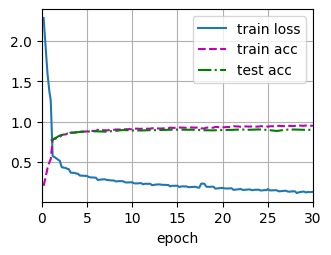

In [4]:
lr, num_epochs = 0.3, 30
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device)

---

## 学习率调度器

我们可以在每个迭代轮数（甚至在每个小批量）之后向下调整学习率。例如，以动态的方式来响应优化的进展情况。


In [5]:
lr = 0.1
trainer.param_groups[0]["lr"] = lr
print(f'learning rate is now {trainer.param_groups[0]["lr"]:.2f}')

learning rate is now 0.10


更通常而言，我们应该定义一个调度器。当调用更新次数时，它将返回学习率的适当值。让我们定义一个简单的方法，将学习率设置为$\eta = \eta_0 (t + 1)^{-\frac{1}{2}}$。


In [6]:
class SquareRootScheduler:
    def __init__(self, lr=0.1):
        self.lr = lr

    def __call__(self, num_update):
        return self.lr * pow(num_update + 1.0, -0.5)

让我们在一系列值上绘制它的行为。


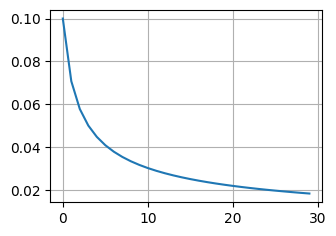

In [7]:
scheduler = SquareRootScheduler(lr=0.1)
plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">scheduler = SquareRootScheduler(lr=0.1)
d2l.plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)]))</pre>
<img src="./images/11.11.1.png" width="300">
  </div>
</details>

现在让我们来看看这对在Fashion-MNIST数据集上的训练有何影响。
我们只是提供调度器作为训练算法的额外参数。


train loss 0.282, train acc 0.897, test acc 0.880


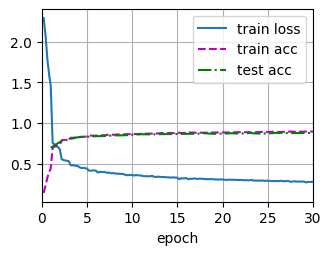

In [8]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device,
      scheduler)

这比以前好一些：曲线比以前更加平滑，并且过拟合更小了。遗憾的是，关于为什么在理论上某些策略会导致较轻的过拟合，有一些观点认为，较小的步长将导致参数更接近零，因此更简单。但是，这并不能完全解释这种现象，因为我们并没有真正地提前停止，而只是轻柔地降低了学习率。

---

## 策略

虽然我们不可能涵盖所有类型的学习率调度器，但我们会尝试在下面简要概述常用的策略：多项式衰减和分段常数表。此外，余弦学习率调度在实践中的一些问题上运行效果很好。在某些问题上，最好在使用较高的学习率之前预热优化器。

---

### 单因子调度器

多项式衰减的一种替代方案是乘法衰减，即$\eta_{t+1} \leftarrow \eta_t \cdot \alpha$其中$\alpha \in (0, 1)$。为了防止学习率衰减到一个合理的下界之下，更新方程经常修改为$\eta_{t+1} \leftarrow \mathop{\mathrm{max}}(\eta_{\mathrm{min}}, \eta_t \cdot \alpha)$。


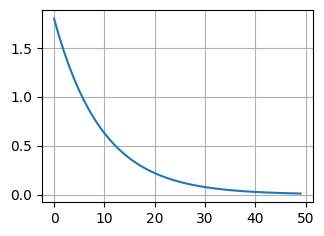

In [9]:
class FactorScheduler:
    def __init__(self, factor=1, stop_factor_lr=1e-7, base_lr=0.1):
        self.factor = factor
        self.stop_factor_lr = stop_factor_lr
        self.base_lr = base_lr

    def __call__(self, num_update):
        self.base_lr = max(self.stop_factor_lr, self.base_lr * self.factor)
        return self.base_lr

scheduler = FactorScheduler(factor=0.9, stop_factor_lr=1e-2, base_lr=2.0)
plot(torch.arange(50), [scheduler(t) for t in range(50)])

接下来，我们将使用内置的调度器，但在这里仅解释它们的功能。

---

### 多因子调度器

训练深度网络的常见策略之一是保持学习率为一组分段的常量，并且不时地按给定的参数对学习率做乘法衰减。具体地说，给定一组降低学习率的时间点，例如$s = \{5, 10, 20\}$，每当$t \in s$时，降低$\eta_{t+1} \leftarrow \eta_t \cdot \alpha$。假设每步中的值减半，我们可以按如下方式实现这一点。


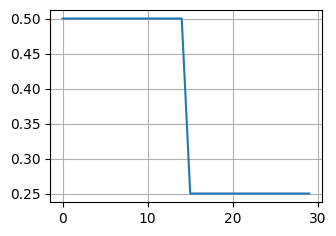

In [10]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
scheduler = lr_scheduler.MultiStepLR(trainer, milestones=[15, 30], gamma=0.5)

def get_lr(trainer, scheduler):
    lr = scheduler.get_last_lr()[0]
    trainer.step()
    scheduler.step()
    return lr

plot(torch.arange(num_epochs), [get_lr(trainer, scheduler)
                                  for t in range(num_epochs)])

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
scheduler = lr_scheduler.MultiStepLR(trainer, milestones=[15, 30], gamma=0.5)

def get_lr(trainer, scheduler):
    lr = scheduler.get_last_lr()[0]
    trainer.step()
    scheduler.step()
    return lr

d2l.plot(torch.arange(num_epochs), [get_lr(trainer, scheduler)
                                  for t in range(num_epochs)])</pre>
<img src="./images/11.11.2.png" width="300">
  </div>
</details>

这种分段恒定学习率调度背后的直觉是，让优化持续进行，直到权重向量的分布达到一个驻点。此时，我们才将学习率降低，以获得更高质量的代理来达到一个良好的局部最小值。下面的例子展示了如何使用这种方法产生更好的解决方案。


train loss 0.182, train acc 0.932, test acc 0.903


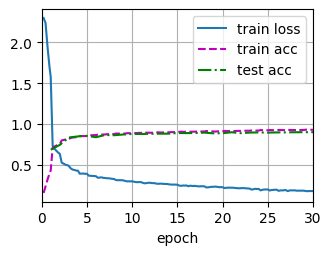

In [11]:
train(net, train_iter, test_iter, num_epochs, loss, trainer, device,
      scheduler)

---

### 余弦调度器

余弦调度器是 ([Loshchilov.Hutter.2016](https://zh.d2l.ai/chapter_references/zreferences.html#id101))提出的一种启发式算法。它所依据的观点是：我们可能不想在一开始就太大地降低学习率，而且可能希望最终能用非常小的学习率来“改进”解决方案。这产生了一个类似于余弦的调度，函数形式如下所示，学习率的值在$t \in [0, T]$之间。

$$\eta_t = \eta_T + \frac{\eta_0 - \eta_T}{2} \left(1 + \cos(\pi t/T)\right)\tag{11.11.1}$$

这里$\eta_0$是初始学习率，$\eta_T$是当$T$时的目标学习率。此外，对于$t > T$，我们只需将值固定到$\eta_T$而不再增加它。在下面的示例中，我们设置了最大更新步数$T = 20$。


In [14]:
class CosineScheduler:
    def __init__(self, max_update, base_lr=0.01, final_lr=0,
               warmup_steps=0, warmup_begin_lr=0):
        self.base_lr_orig = base_lr
        self.max_update = max_update
        self.final_lr = final_lr
        self.warmup_steps = warmup_steps
        self.warmup_begin_lr = warmup_begin_lr
        self.max_steps = self.max_update - self.warmup_steps

    def get_warmup_lr(self, epoch):
        increase = (self.base_lr_orig - self.warmup_begin_lr) \
                       * float(epoch) / float(self.warmup_steps)
        return self.warmup_begin_lr + increase

    def __call__(self, epoch):
        if epoch < self.warmup_steps:
            return self.get_warmup_lr(epoch)
        if epoch <= self.max_update:
            self.base_lr = self.final_lr + (
                self.base_lr_orig - self.final_lr) * (1 + math.cos(
                math.pi * (epoch - self.warmup_steps) / self.max_steps)) / 2
        return self.base_lr



<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">class CosineScheduler:
    def __init__(self, max_update, base_lr=0.01, final_lr=0,
               warmup_steps=0, warmup_begin_lr=0):
        self.base_lr_orig = base_lr
        self.max_update = max_update
        self.final_lr = final_lr
        self.warmup_steps = warmup_steps
        self.warmup_begin_lr = warmup_begin_lr
        self.max_steps = self.max_update - self.warmup_steps
    def get_warmup_lr(self, epoch):
        increase = (self.base_lr_orig - self.warmup_begin_lr) \
                       * float(epoch) / float(self.warmup_steps)
        return self.warmup_begin_lr + increase
    def __call__(self, epoch):
        if epoch < self.warmup_steps:
            return self.get_warmup_lr(epoch)
        if epoch <= self.max_update:
            self.base_lr = self.final_lr + (
                self.base_lr_orig - self.final_lr) * (1 + math.cos(
                math.pi * (epoch - self.warmup_steps) / self.max_steps)) / 2
        return self.base_lr
scheduler = CosineScheduler(max_update=20, base_lr=0.3, final_lr=0.01)
d2l.plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])</pre>
<img src="./images/11.11.3.png" width="300">
  </div>
</details>

在计算机视觉的背景下，这个调度方式可能产生改进的结果。
但请注意，如下所示，这种改进并不一定成立。


train loss 0.186, train acc 0.932, test acc 0.901


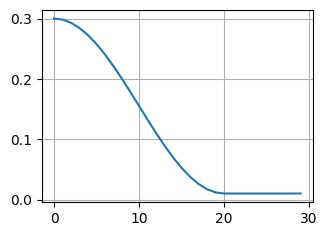

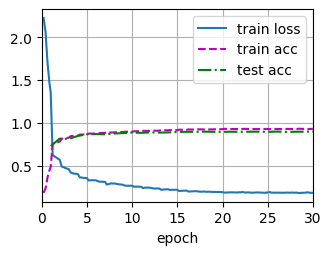

In [15]:
scheduler = CosineScheduler(max_update=20, base_lr=0.3, final_lr=0.01)
plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=0.3)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device,
      scheduler)

---

### 预热

在某些情况下，初始化参数不足以得到良好的解。这对某些高级网络设计来说尤其棘手，可能导致不稳定的优化结果。对此，一方面，我们可以选择一个足够小的学习率，从而防止一开始发散，然而这样进展太缓慢。另一方面，较高的学习率最初就会导致发散。

解决这种困境的一个相当简单的解决方法是使用预热期，在此期间学习率将增加至初始最大值，然后冷却直到优化过程结束。为了简单起见，通常使用线性递增。这引出了如下表所示的时间表。


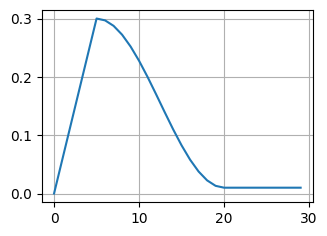

In [16]:
scheduler = CosineScheduler(20, warmup_steps=5, base_lr=0.3, final_lr=0.01)
plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">scheduler = CosineScheduler(20, warmup_steps=5, base_lr=0.3, final_lr=0.01)
d2l.plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])</pre>
<img src="./images/11.11.4.png" width="300">
  </div>
</details>

注意，观察前5个迭代轮数的性能，网络最初收敛得更好。


train loss 0.206, train acc 0.924, test acc 0.900


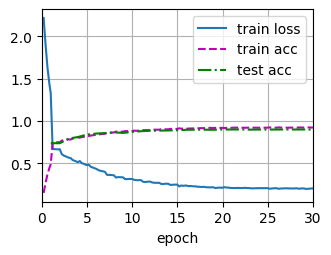

In [17]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=0.3)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device,
      scheduler)

预热可以应用于任何调度器，而不仅仅是余弦。有关学习率调度的更多实验和更详细讨论，请参阅 ([Gotmare.Keskar.Xiong.ea.2018](https://zh.d2l.ai/chapter_references/zreferences.html#id49))。其中，这篇论文的点睛之笔的发现：预热阶段限制了非常深的网络中参数的发散程度 。这在直觉上是有道理的：在网络中那些一开始花费最多时间取得进展的部分，随机初始化会产生巨大的发散。

---

## 小结

* 在训练期间逐步降低学习率可以提高准确性，并且减少模型的过拟合。
* 在实验中，每当进展趋于稳定时就降低学习率，这是很有效的。从本质上说，这可以确保我们有效地收敛到一个适当的解，也只有这样才能通过降低学习率来减小参数的固有方差。
* 余弦调度器在某些计算机视觉问题中很受欢迎。
* 优化之前的预热期可以防止发散。
* 优化在深度学习中有多种用途。对于同样的训练误差而言，选择不同的优化算法和学习率调度，除了最大限度地减少训练时间，可以导致测试集上不同的泛化和过拟合量。

---

## 练习

1. 试验给定固定学习率的优化行为。这种情况下可以获得的最佳模型是什么？
1. 如果改变学习率下降的指数，收敛性会如何改变？在实验中方便起见，使用`PolyScheduler`。
1. 将余弦调度器应用于大型计算机视觉问题，例如训练ImageNet数据集。与其他调度器相比，它如何影响性能？
1. 预热应该持续多长时间？
1. 可以试着把优化和采样联系起来吗？首先，在随机梯度朗之万动力学上使用 ([Welling.Teh.2011](https://zh.d2l.ai/chapter_references/zreferences.html#id181))的结果。

详细参考答案见[11.11_reference_answer](./answers/11.11_reference_answer.ipynb)


#### **参考答案(PyPTO 版)**

In [ ]:
!cat ./answers/txt/11.11_reference_pypto.txt


#### **参考答案(PyTorch 版)**

In [ ]:
!cat ./answers/txt/11.11_reference_pytorch.txt
